# Importing nessesary libraries to do EDA

<b>Pandas library is used for Data manipulation and analysis</b>
pandas provides DataFrame and series structure, which make it easy to work with tabular data.
Common EDA uses of Pandas Library are
1. Load datasets from csv , excel, sql, etc.
2. view data structure and summary statistics
3. handling missing valuse
4. filter, sort, and group data
5. create new columns and transform data
   
<b> Numpy library is used for computing and mathematical operations.</b>
Numpy provides fast operations on arrays and mathematical operations
common EDA uses of Numpy library
1. statistical calculations
2. Handling numerical arrays
3. Mathematical Transfermations
4. Generating random numberss for simulations

<b>Matplotlib library for Data visulizations</b>
Matplotlib is the foundation of creating charts and graphs
common EDA uses of Matplotlib library
1. line charts
2. bar charts
3. Histograms
4. scatter plots
5. custom chart formatting

<b>Seaborn library is used for advanced statistical visulization</b>
Seaborn is built on top of Matplotlib and provides more attractive and informative plots with less code
Common EDA uses of Seaborn library 
1. correlation heatmaps
2. box plots
3. distribution plots
4. pair plot
5. categorical analysis


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


read.csv is pandas function to load data from csv and df2 is variable name of the data set

In [3]:
df = pd.read_csv ("Cardiotocographic.csv")

df2.head() is used to check the first 5 rows of the data set . 

In [4]:
df.head()



,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


# Dataset:
1.	LB - Likely stands for "Baseline Fetal Heart Rate (FHR)" which represents the average fetal heart rate over a period.
2.	AC - Could represent "Accelerations" in the FHR. Accelerations are usually a sign of fetal well-being.
3.	FM - May indicate "Fetal Movements" detected by the monitor.
4.	UC - Likely denotes "Uterine Contractions", which can impact the FHR pattern.
5.	DL - Could stand for "Decelerations Late" with respect to uterine contractions, which can be a sign of fetal distress.
6.	DS - May represent "Decelerations Short" or decelerations of brief duration.
7.	DP - Could indicate "Decelerations Prolonged", or long-lasting decelerations.
8.	ASTV - Might refer to "Percentage of Time with Abnormal Short Term Variability" in the FHR.
9.	MSTV - Likely stands for "Mean Value of Short Term Variability" in the FHR.
10.	ALTV - Could represent "Percentage of Time with Abnormal Long Term Variability" in the FHR.
11.	MLTV - Might indicate "Mean Value of Long Term Variability" in the FHR.


In [5]:
# view data stucture and dimesions
df.info()
print("Dataset Shape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB
Dataset Shape: (2126, 14)


In [6]:
# Data Cleaning
#Check for missing values in each column
print("Missing Values:",df.isnull().sum())

Missing Values: LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64


In [7]:
# Fill missing numerical values using the median
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

In [8]:
df.dtypes

LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Tendency    float64
NSP         float64
dtype: object

In [9]:
# Convert columns to numeric data types where possible
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')


C:\Users\AD1HCZZ\AppData\Local\Temp\ipykernel_444\2538593320.py:3: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


In [10]:
# Verify data types after conversion
print(df.dtypes)

LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Tendency    float64
NSP         float64
dtype: object


In [11]:
# -------------------------
# 3. Handle Outliers
# -------------------------

# Select all numerical columns
num_cols = df.select_dtypes(include=np.number).columns

# Apply IQR method to cap extreme values
for col in num_cols:

    # Calculate first and third quartiles
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # Calculate Interquartile Range
    IQR = Q3 - Q1

    # Define lower and upper boundaries
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap lower outliers
    df[col] = np.where(df[col] < lower_bound,
                       lower_bound,
                       df[col])

    # Cap upper outliers
    df[col] = np.where(df[col] > upper_bound,
                       upper_bound,
                       df[col])



In [12]:
print("Q1=",Q1)
print("Q3=",Q3)
print("IQR=", IQR)
print(lower_bound,"," ,upper_bound)

Q1= 1.0
Q3= 1.0
IQR= 0.0
1.0 , 1.0


In [13]:
df.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,27.5,2.4,64.0,0.999926,1.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,20.1,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [14]:
# 4. Statistical Summary
# Generate descriptive statistics
summary = df.describe()

In [15]:
summary

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.0,2126.0,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.0
mean,133.290331,0.003132,0.001568,0.004362,0.001770,0.0,0.0,46.981873,1.304644,6.691678,8.007471,70.287203,0.316537,1.0
std,9.930268,0.003828,0.002485,0.003001,0.002668,0.0,0.0,17.612745,0.781091,10.378400,5.047078,39.571995,0.622406,0.0
min,105.000000,-0.008409,-0.003850,-0.005177,-0.004934,0.0,0.0,-11.500000,-0.800000,-16.500000,-4.700000,-57.500000,-1.500000,1.0
25%,126.000000,0.000000,0.000000,0.001851,0.000000,0.0,0.0,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.0
50%,133.000000,0.001634,0.000000,0.004484,0.000000,0.0,0.0,49.000000,1.200000,0.000000,7.400000,67.000000,0.000000,1.0
75%,140.000000,0.005606,0.002567,0.006536,0.003289,0.0,0.0,61.000000,1.700000,11.000000,10.800000,100.000000,1.000000,1.0
max,161.000000,0.014015,0.006416,0.013564,0.008224,0.0,0.0,104.500000,3.200000,27.500000,20.100000,194.500000,2.500000,1.0


In [16]:
# Add median values
summary['Median'] = df.median(numeric_only=True)


In [17]:
# Add Interquartile Range (IQR)
summary['IQR'] = (
    df.quantile(0.75, numeric_only=True)
    - df.quantile(0.25, numeric_only=True))

In [20]:
summary.describe().T

,count,mean,std,min,25%,50%,75%,max
LB,8.0,366.777575,712.304671,9.930268,120.750000,133.145165,145.250000,2126.0
AC,8.0,265.752476,751.653508,-0.008409,0.001225,0.003480,0.007708,2126.0
FM,8.0,265.751148,751.654044,-0.003850,0.000000,0.002026,0.003529,2126.0
UC,8.0,265.753578,751.653063,-0.005177,0.002714,0.004423,0.008293,2126.0
DL,8.0,265.751377,751.653952,-0.004934,0.000000,0.002219,0.004523,2126.0
DS,8.0,265.750000,751.654508,0.000000,0.000000,0.000000,0.000000,2126.0
DP,8.0,265.750000,751.654508,0.000000,0.000000,0.000000,0.000000,2126.0
ASTV,8.0,303.199327,737.287824,-11.500000,28.403186,47.990937,71.875000,2126.0
MSTV,8.0,266.760717,751.246942,-0.800000,0.760819,1.252322,2.075000,2126.0
ALTV,8.0,270.633760,749.784439,-16.500000,0.000000,8.535039,15.125000,2126.0


In [21]:
# Add median values
summary['Median'] = df.median(numeric_only=True)

In [23]:
# Add Interquartile Range (IQR)
summary['IQR'] = (
    df.quantile(0.75, numeric_only=True)
    - df.quantile(0.25, numeric_only=True))


In [24]:
# Display summary statistics
summary


,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP,Median,IQR
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.0,2126.0,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.0,NaN,NaN
mean,133.290331,0.003132,0.001568,0.004362,0.001770,0.0,0.0,46.981873,1.304644,6.691678,8.007471,70.287203,0.316537,1.0,NaN,NaN
std,9.930268,0.003828,0.002485,0.003001,0.002668,0.0,0.0,17.612745,0.781091,10.378400,5.047078,39.571995,0.622406,0.0,NaN,NaN
min,105.000000,-0.008409,-0.003850,-0.005177,-0.004934,0.0,0.0,-11.500000,-0.800000,-16.500000,-4.700000,-57.500000,-1.500000,1.0,NaN,NaN
25%,126.000000,0.000000,0.000000,0.001851,0.000000,0.0,0.0,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.0,NaN,NaN
50%,133.000000,0.001634,0.000000,0.004484,0.000000,0.0,0.0,49.000000,1.200000,0.000000,7.400000,67.000000,0.000000,1.0,NaN,NaN
75%,140.000000,0.005606,0.002567,0.006536,0.003289,0.0,0.0,61.000000,1.700000,11.000000,10.800000,100.000000,1.000000,1.0,NaN,NaN
max,161.000000,0.014015,0.006416,0.013564,0.008224,0.0,0.0,104.500000,3.200000,27.500000,20.100000,194.500000,2.500000,1.0,NaN,NaN


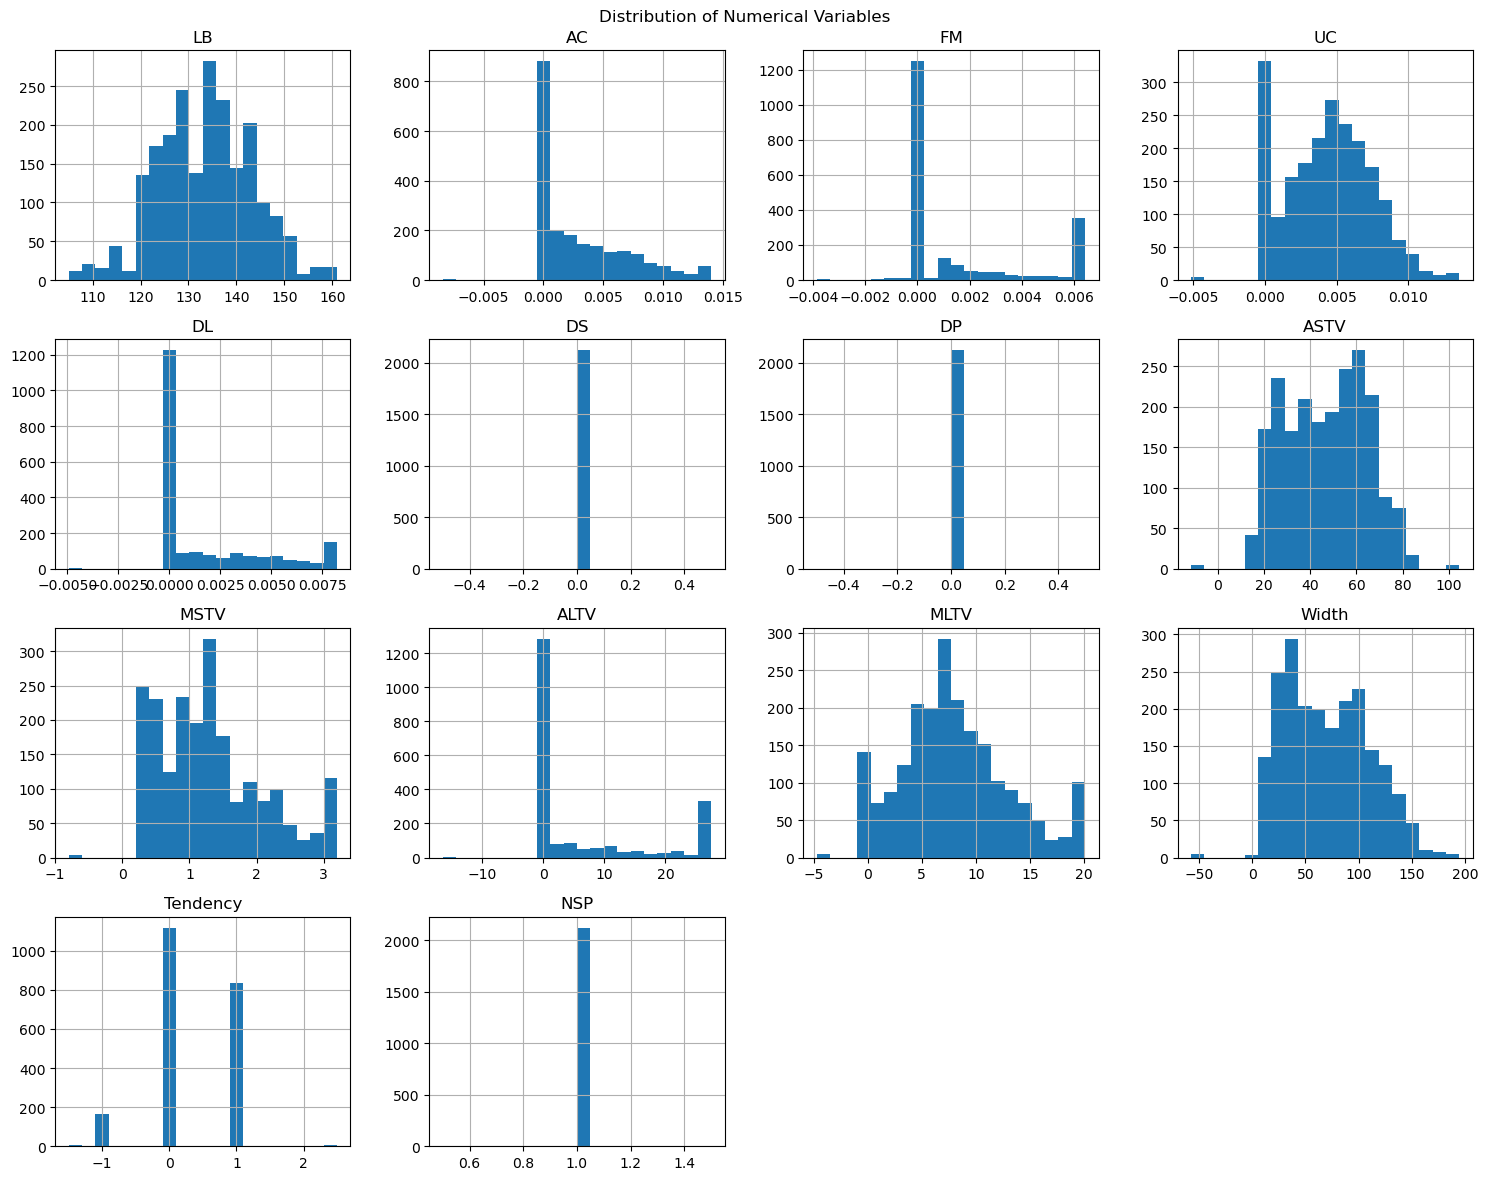

In [25]:
# -------------------------
# 5. Histograms
# -------------------------

# Plot histogram for all numerical features
df.hist(figsize=(15, 12), bins=20)

plt.suptitle("Distribution of Numerical Variables")
plt.tight_layout()
plt.show()



<b><u>  Overall Findings </b></u>

The dataset contains a mix of:

Normally distributed variables (LB, MLTV, partially Width)
Highly right-skewed variables (AC, UC, ASTV, MSTV)
Zero-inflated variables (FM, DL, ALTV)
Near-constant variables (DS, DP, NSP)
Discrete/Categorical encoded variables (Tendency, NSP)

This suggests that preprocessing steps such as skewness treatment, outlier detection, and feature scaling may be required before modeling.

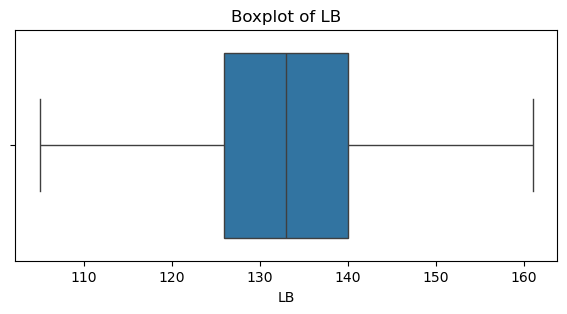

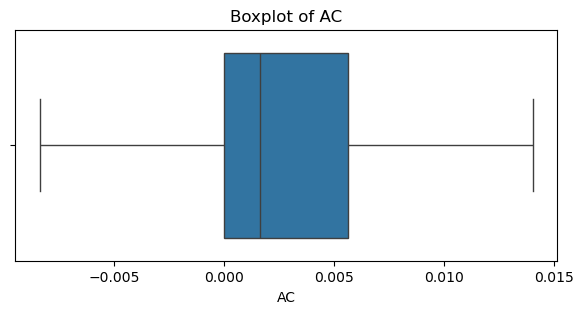

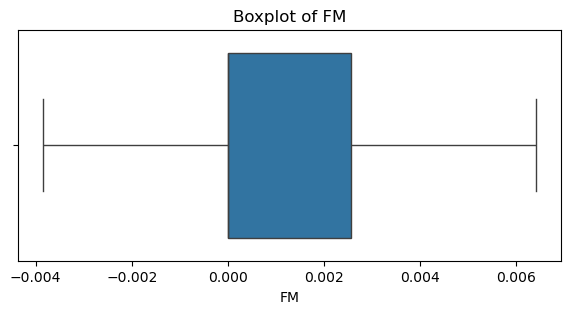

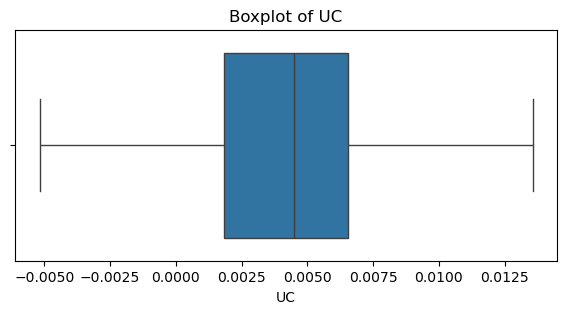

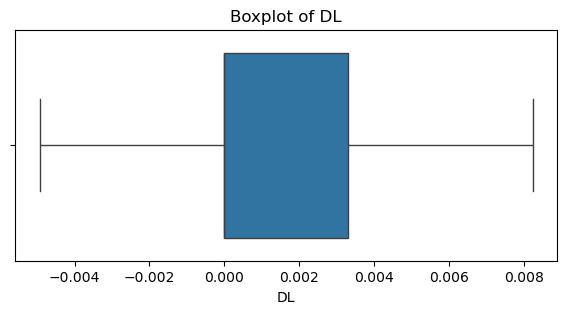

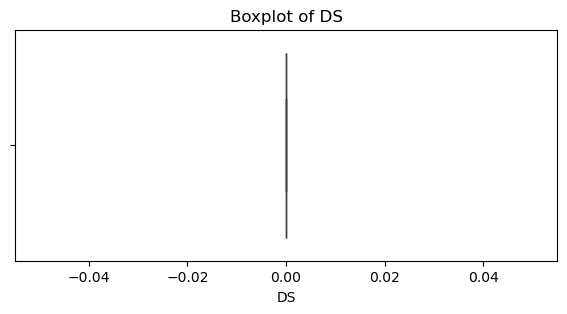

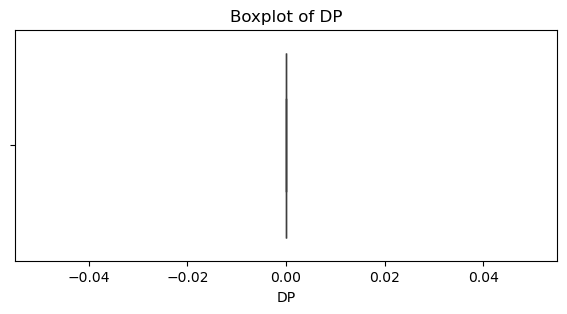

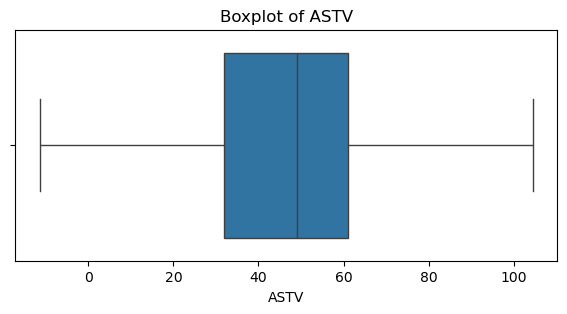

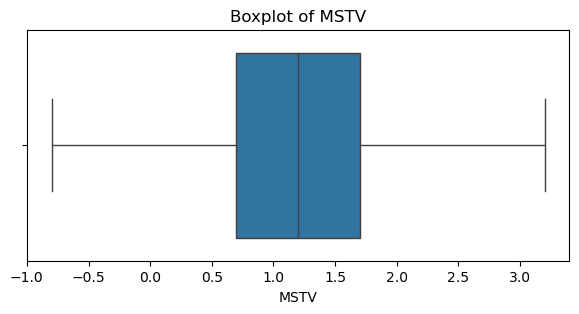

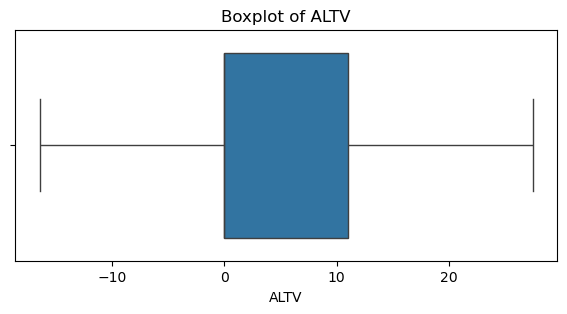

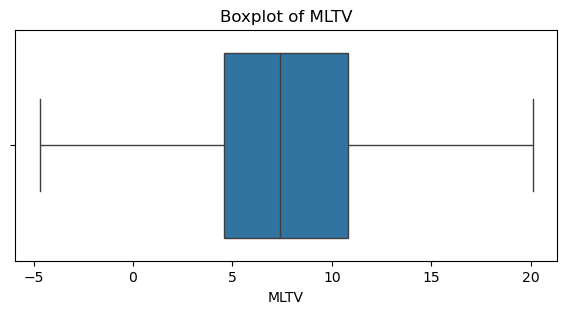

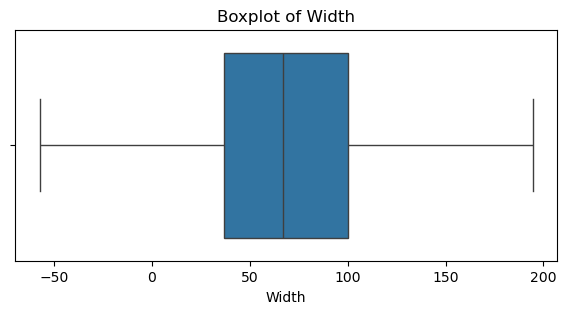

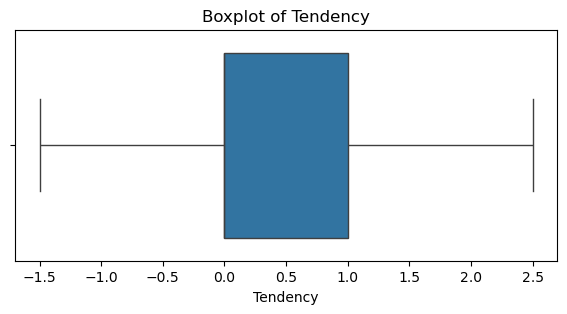

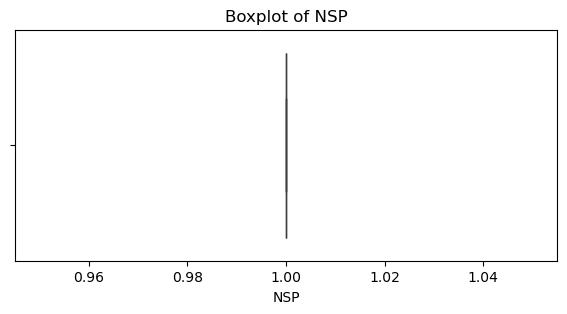

In [26]:
# -------------------------
# 6. Boxplots
# -------------------------

# Visualize outliers and spread of each feature
for col in num_cols:

    plt.figure(figsize=(7, 3))

    sns.boxplot(x=df[col])

    plt.title(f'Boxplot of {col}')

    plt.show()



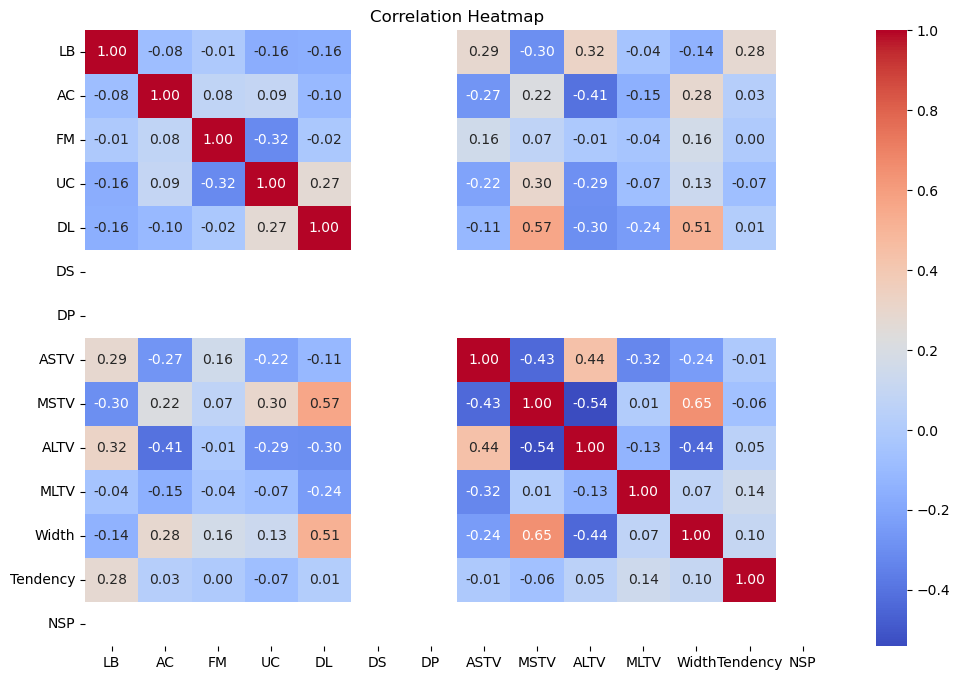

In [27]:

# -------------------------
# 7. Correlation Analysis
# -------------------------

# Calculate correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()


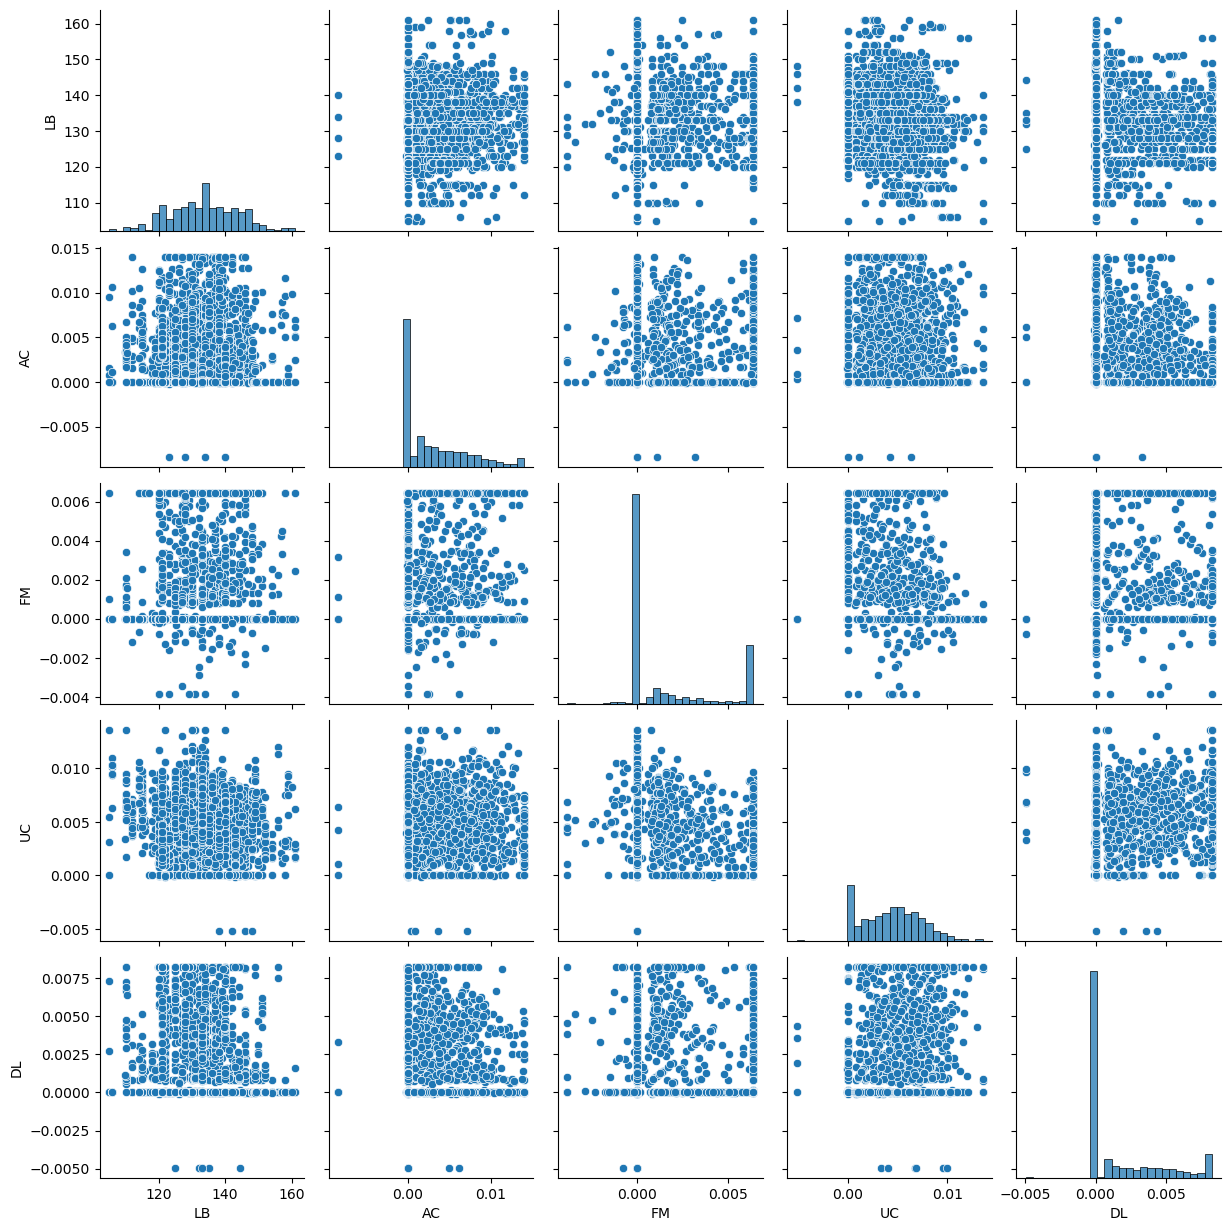

In [28]:
# -------------------------
# 8. Pair Plot
# -------------------------

# Pairwise relationship analysis for selected features
sns.pairplot(df[num_cols[:5]])

plt.show()

